# Analisis Komprehensif UMKM Provinsi di Indonesia (ACW Stan)

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 1. Data Loading & Cleaning

In [2]:

# Load Dataset
file_path = r"C:/Uner/Lomba/ACW Stan/Dataset/Dataset_Gabungan_UMKM_Provinsi.csv"
df = pd.read_csv(file_path)

print("Dataset Info:")
df.info()
print("\nFirst 5 Rows:")
display(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Provinsi               50 non-null     object 
 1   Angkatan_Kerja_2025    38 non-null     float64
 2   Perusahaan_Mikro_2023  38 non-null     float64
 3   Perusahaan_Kecil_2023  38 non-null     float64
 4   TK_Mikro_2023          38 non-null     float64
 5   TK_Kecil_2023          38 non-null     float64
 6   Output_Mikro_2023      38 non-null     float64
 7   Output_Kecil_2023      38 non-null     float64
 8   Persen_Formal_2023     34 non-null     float64
 9   Persen_Informal_2023   34 non-null     float64
 10  Rata_Upah_Feb_2023     35 non-null     float64
 11  TPT_Feb_2025           38 non-null     float64
 12  Tamat_SD_2023          34 non-null     float64
 13  Tamat_SMP_2023         34 non-null     float64
 14  Tamat_SMA_2023         34 non-null     float64

,Provinsi,Angkatan_Kerja_2025,Perusahaan_Mikro_2023,Perusahaan_Kecil_2023,TK_Mikro_2023,TK_Kecil_2023,Output_Mikro_2023,Output_Kecil_2023,Persen_Formal_2023,Persen_Informal_2023,Rata_Upah_Feb_2023,TPT_Feb_2025,Tamat_SD_2023,Tamat_SMP_2023,Tamat_SMA_2023,Produktivitas_Mikro,Produktivitas_Kecil
0,ACEH,2704621.0,106527.0,3999.0,174854.0,24650.0,7840333.0,2092181.0,40.14,59.86,4276244.0,5.50,99.08,94.55,74.46,44.839312,84.875497
1,SUMATERA UTARA,8108338.0,119539.0,7368.0,211161.0,53998.0,11334254.0,3744842.0,41.48,58.52,3112921.0,5.05,98.75,94.35,74.43,53.675887,69.351494
2,SUMATERA BARAT,3157912.0,84077.0,4144.0,141426.0,27270.0,8303610.0,4331998.0,35.81,64.19,3527098.0,5.69,95.81,90.65,68.64,58.713461,158.855812
3,RIAU,3224809.0,60273.0,2090.0,108381.0,15415.0,6861660.0,1464036.0,47.87,52.13,3628740.0,4.12,98.09,90.52,67.79,63.310543,94.974765
4,JAMBI,1884335.0,33742.0,792.0,57183.0,5333.0,3754580.0,367439.0,40.27,59.73,3838181.0,4.48,97.76,89.35,66.62,65.659025,68.899119


In [3]:

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Ensure Province names are standardized if needed (Basic strip)
df['Provinsi'] = df['Provinsi'].str.strip()

# Create additional derived metrics if not already present or helpful
# (The dataset already has Productivity, but we can verify)



Missing Values:
Provinsi                  0
Angkatan_Kerja_2025      12
Perusahaan_Mikro_2023    12
Perusahaan_Kecil_2023    12
TK_Mikro_2023            12
TK_Kecil_2023            12
Output_Mikro_2023        12
Output_Kecil_2023        12
Persen_Formal_2023       16
Persen_Informal_2023     16
Rata_Upah_Feb_2023       15
TPT_Feb_2025             12
Tamat_SD_2023            16
Tamat_SMP_2023           16
Tamat_SMA_2023           16
Produktivitas_Mikro      16
Produktivitas_Kecil      16
dtype: int64


## 2. Exploratory Data Analysis (EDA)

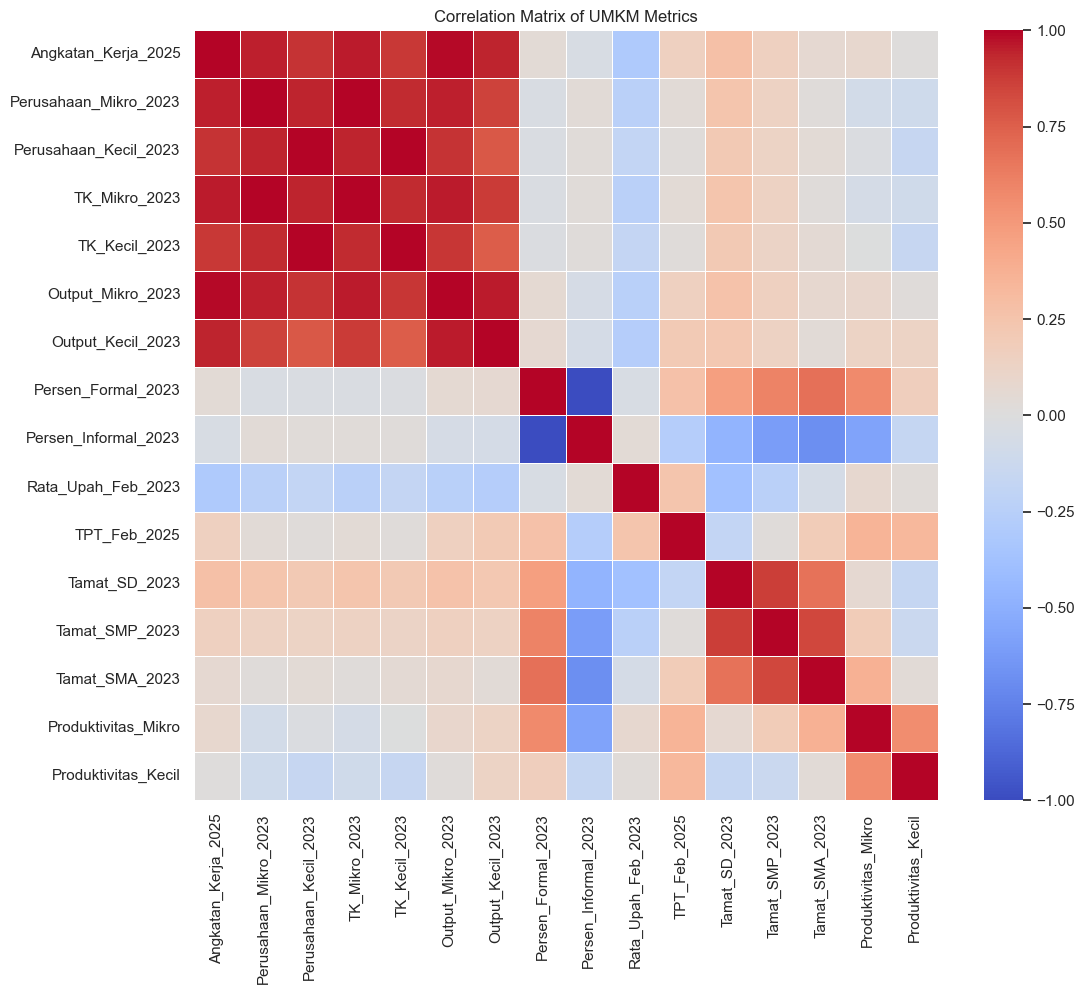

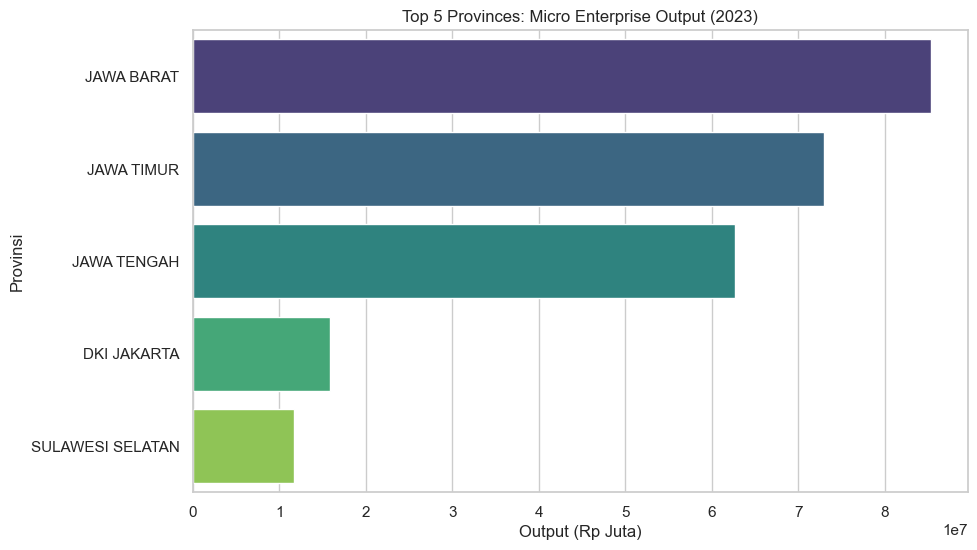

In [4]:

# Correlation Matrix
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of UMKM Metrics")
plt.show()

# Top 5 Provinces by Micro Enterprise Output
top_output = df.nlargest(5, 'Output_Mikro_2023')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_output, y='Provinsi', x='Output_Mikro_2023', palette='viridis')
plt.title("Top 5 Provinces: Micro Enterprise Output (2023)")
plt.xlabel("Output (Rp Juta)")
plt.show()


## 3. Data Preprocessing & Clustering (K-Means)

In [5]:

# Select Features for Clustering
# We focus on the core UMKM metrics: Units, Labor, Output, Productivity
features = [
    'Perusahaan_Mikro_2023', 'Perusahaan_Kecil_2023',
    'TK_Mikro_2023', 'TK_Kecil_2023',
    'Output_Mikro_2023', 'Output_Kecil_2023',
    'Produktivitas_Mikro', 'Produktivitas_Kecil'
]

X = df[features]

# Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA for Dimensionality Reduction (Optional but good for viz)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Provinsi'] = df['Provinsi']

print(f"Explained Variance Ratio by PCA: {pca.explained_variance_ratio_}")


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:

# Determine Optimal K (Elbow Method)
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(K_range, inertia, 'o-', color='blue', label='Inertia')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Analysis')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'o--', color='red', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')

plt.show()

# Based on typical results, let's choose K=3 (Low, Medium, High Performance)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Add PCA coordinates for visualization
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Analyze Clusters
cluster_summary = df.groupby('Cluster')[features].mean()
display(cluster_summary)

# Visualizing Clusters on PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='deep', s=100)
for i in range(df.shape[0]):
    plt.text(df.PC1[i]+0.02, df.PC2[i], df.Provinsi[i], fontsize=8)
plt.title("Cluster Visualization (PCA)")
plt.show()


## 4. Analisis Spasial (Peta Sebaran)

In [ ]:

# Load Shapefile
# Path identified from local files
shp_path = r"C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp"

try:
    gdf = gpd.read_file(shp_path)
    print("Shapefile Loaded Successfully.")
    
    # Check column names for merging
    # GADM usually uses NAME_1 for Province
    # We might need to standardize names (e.g. 'Jakarta Raya' -> 'DKI Jakarta')
    
    # Simple name mapping (Example - adjust based on actual mismatch inspection)
    # gdf['NAME_1'] = gdf['NAME_1'].replace({'Jakarta Raya': 'DKI Jakarta', 'Yogyakarta': 'DI Yogyakarta'})
    
    # Merge
    # Attempt merge on Name
    gdf_merged = gdf.merge(df, how='left', left_on='NAME_1', right_on='Provinsi')
    
    # Check for unmerged provinces
    unmerged = df[~df['Provinsi'].isin(gdf_merged['Provinsi'])]
    if not unmerged.empty:
        print("Warning: Some provinces failed to merge. Check name variants:")
        print(unmerged['Provinsi'].tolist())

    # Plot Cluster Map
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    gdf_merged.plot(column='Cluster', ax=ax, legend=True, 
                    categorical=True, legend_kwds={'title': "Cluster"},
                    cmap='viridis')
    ax.set_title("Peta Sebaran Klaster UMKM Indonesia", fontsize=15)
    ax.set_axis_off()
    plt.show()

    # Plot Productivity Map
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    gdf_merged.plot(column='Produktivitas_Mikro', ax=ax, legend=True,
                    legend_kwds={'label': "Produktivitas Mikro", 'orientation': "horizontal"},
                    cmap='OrRd')
    ax.set_title("Peta Produktivitas UMKM Mikro", fontsize=15)
    ax.set_axis_off()
    plt.show()

except Exception as e:
    print(f"Error in Spatial Analysis: {e}")
    print("Please verify the shapefile path and column names.")
